# 06. Recurrent Neural Networks

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2026-03-16">16 Mar 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/notebooks/06_rnn.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
  />
</a>


Up until this point, our neural network inputs had fixed size (e.g. an image had a fixed height and width). In _sequences_, however, order matters, and the number of steps may vary:

- a sentence is a sequence of words or characters
- a stock signal is a sequence of prices
- a video is a sequence of frames
- a patient history is a sequence of events

This simple change creates a big modeling problem. The number of steps is not known in advance and can vary widely, so the model cannot rely on a different set of parameters for each position in the sequence. 

Imagine designing a model where step 1 uses parameters $W_1$, step 2 uses $W_2$​, step 3 uses $W_3$, and so on. First, the architecture would only work for a fixed sequence length. If the model was built for sequences of length 20, it would simply have no parameters for step 21. Second, learning would become extremely inefficient. Each step-specific parameter would only be trained using data from that particular position in the sequence. The model would have to learn hundreds or thousands of separate rules instead of learning a single general rule that applies everywhere. Third, most sequential processes follow the same underlying dynamics over time. The rule for interpreting the next word in a sentence does not fundamentally change between the beginning and the end of the sentence. Similarly, the physical rules governing motion in video frames are the same at every time step. Because the process itself is repetitive, the model should learn one update rule that can be applied repeatedly.

**Sequence modeling** (unsupervised density modeling) has the goal of estimating the probability distribution of a sequence, $p(\mathbf{x}_1, \ldots, \mathbf{x}_T)$, without predicting a specific target. For the aformentioned reasons, sequence models use parameter sharing across time. The model learns a single function that updates a running summary of the past using the current input. This function is applied again and again as the sequence progresses, allowing the model to process sequences of any length while gradually accumulating information about what has happened so far.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    In sequences the order carries meaning. If we shuffle the words of a sentence, the meaning changes. If we shuffle the frames of a video, the event changes. Images are different: although they can technically be flattened into a sequence of pixels, their natural structure is spatial (a 2D grid).
  </p>
</div>

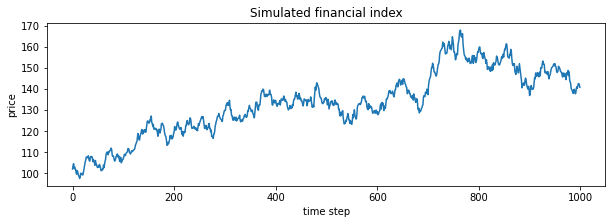

In [51]:
import random
import torch
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(42)
random.seed(42)

T = 1000
time = torch.arange(T, dtype=torch.float32)

start_price = 100
drift = 0.0003
volatility = 0.01

returns = drift + volatility * torch.randn(T)
price = start_price * torch.exp(torch.cumsum(returns, dim=0))

plt.figure(figsize=(10, 3))
plt.plot(time, price)
plt.title('Simulated financial index')
plt.xlabel('time step')
plt.ylabel('price')
plt.show()

## Autoregressive Modeling

One of the most common sequence tasks is to predict the next value from previous values. This is called [autoregressive modeling](https://en.wikipedia.org/wiki/Autoregressive_model). It appears in many domains, including time series forecasting, language modeling, audio generation, financial prediction, and several classes of generative models. Suppose we observe a sequence of values $x_1, x_2, \dots, x_{t-1}.$ If we want to predict the next value $x_t$, the only available signal may be the past observations themselves. Ideally, we would like to estimate the conditional distribution

$$
P(x_t \mid x_{t-1}, x_{t-2}, \dots, x_1).
$$

In practice, modeling the entire distribution of a continuous variable can be difficult. A common simplification is to estimate a summary statistic, such as the conditional expectation:

$$
\mathbb{E}[x_t \mid x_{t-1}, x_{t-2}, \dots, x_1].
$$

There is an immediate problem, however. The amount of available history grows over time, meaning that the number of input features would continually increase. Standard models such as linear regression or neural networks expect fixed-length input vectors, so directly using the entire past is inconvenient. A simple trick (or rather, compromise) is to use fixed windows. Instead of conditioning on the entire past, we consider only the most recent $\tau$ observations:

$$
\hat{x}_t = f(x_{t-\tau}, \dots, x_{t-1}).
$$

This keeps the number of inputs constant and converts the sequence prediction problem into a standard fixed-input learning problem.

In [52]:
def make_windows(x, tau):
    X, y = [], []
    for t in range(tau, len(x)):
        X.append(x[t - tau:t])
        y.append(x[t])
    return torch.stack(X), torch.tensor(y).unsqueeze(1)

tau = 5
X, y = make_windows(price, tau)

In [53]:
f'Window matrix shape: {X.shape}, Target shape: {y.shape}'

'Window matrix shape: torch.Size([995, 5]), Target shape: torch.Size([995, 1])'

In [60]:
f'First window: {X[0]}, First target: {y[0]}'

'First window: tensor([101.9762, 103.5353, 104.5034, 102.3567, 103.0844]), First target: tensor([101.8502])'

In [55]:
f'Second window: {X[1]}, Second target: {y[0]}'

'Second window: tensor([103.5353, 104.5034, 102.3567, 103.0844, 101.8502]), Second target: tensor([101.8502])'

Instead of predicting directly from the entire history, we approximate the problem by using only the most recent $\tau$ observations. Each window becomes an input vector, and the value immediately following the window becomes the prediction target. For $\tau = 5$, the dataset looks like:

| input window | target |
|---|---|
| $(x_1, x_2, x_3, x_4, x_5)$ | $x_6$ |
| $(x_2, x_3, x_4, x_5, x_6)$ | $x_7$ |
| $(x_3, x_4, x_5, x_6, x_7)$ | $x_8$ |
| $\text{etc.}$ ||

Once the dataset is constructed, we split it into a training and validation portion. Before training, it is also helpful to normalize the data. The following small utility class imitating [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) performs this standardization by subtracting the mean and dividing by the standard deviation computed from the training data.

In [44]:
class StandardScaler:
    def fit(self, x):
        self.mean = x.mean()
        self.std = x.std()
        
    def transform(self, x):
        return (x - self.mean) / self.std
    
    def inverse(self, x):
        return x * self.std + self.mean

In [61]:
import torch.nn as nn
import torch.nn.functional as F

split = 700
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
y_train = scaler.transform(y_train)
y_val = scaler.transform(y_val)

model = nn.Sequential(
    nn.Linear(tau, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

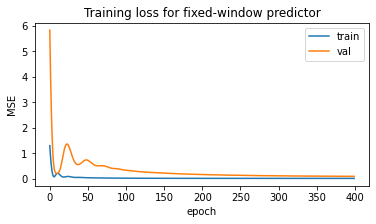

In [62]:
train_losses = []
val_losses = []

for epoch in range(400):
    model.train()
    pred = model(X_train)
    loss = F.mse_loss(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = F.mse_loss(val_pred, y_val)
        
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

plt.figure(figsize=(6, 3))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('Training loss for fixed-window predictor')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

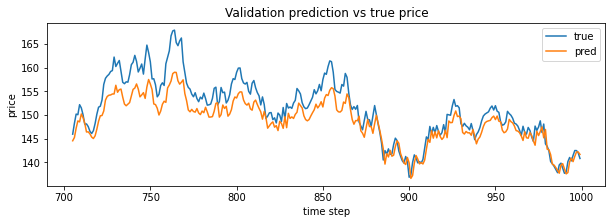

In [46]:
with torch.no_grad():
    pred_val = model(X_val)

pred_val = scaler.inverse(pred_val)
y_val_true = scaler.inverse(y_val)

plt.figure(figsize=(10, 3))
plt.plot(range(split + tau, split + tau + len(y_val_true)), y_val_true.squeeze(), label='true')
plt.plot(range(split + tau, split + tau + len(pred_val)), pred_val.squeeze(), label='pred')
plt.title('Validation prediction vs true price')
plt.xlabel('time step')
plt.ylabel('price')
plt.legend()
plt.show()

The plot above shows the model's one-step predictions compared to the true price sequence on the validation portion of the data. The network is able to capture the general movement of the signal, but its predictions appear noticeably smoother than the true sequence. This happens because the model is trained with mean squared error. When the next value is uncertain, the safest prediction is often a value close to the local average of the recent observations.

Another important limitation comes from the way we constructed the dataset. The model only receives the last $\tau$ values as input. Any information that occurred earlier than this window is completely ignored. In other words, the model has a _fixed memory_ of length $\tau$. While the window approach allows us to use standard neural networks with fixed-size inputs, it is only an approximation to the original autoregressive problem or predicting the distribution.


<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
  Using a fixed window can also be interpreted as making a <a href="https://en.wikipedia.org/wiki/Markov_property">Markov assumption</a>. Instead of conditioning on the entire history, we assume that the next value depends only on the most recent $\tau$ observations:
  $$
  P(x_t \mid x_1,\dots,x_{t-1}) \approx P(x_t \mid x_{t-\tau},\dots,x_{t-1}).
  $$
  
  This is known as a <strong>$\boldsymbol{\tau}$-order Markov assumption</strong>. For the first-order Markov (the window size $\tau = 1$), it leads to:
  $$
  P(x_t \mid x_1,\dots,x_{t-1}) \approx P(x_t \mid x_{t-1}).
  $$
  
  In practice this assumption is rarely exactly true, but the influence of distant history often diminishes. Using a finite window therefore provides a practical approximation that can allow us to train models with fixed-size inputs.
  </p>
</div>

We now may attempt for a multi-step prediction. Unlike one-step  prediction (as above), where the model always receives the true previous values, rollout forecasting feeds the model's own predictions back as future inputs. This makes the task much harder. Any small prediction error becomes part of the next input window, so errors can accumulate over time and the predicted trajectory may drift away from the true sequence.

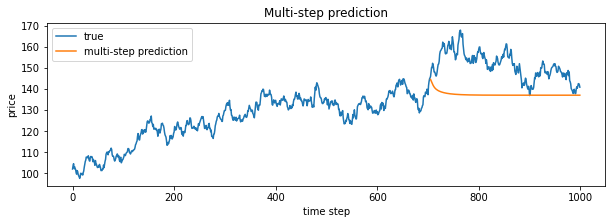

In [63]:
with torch.no_grad():
    rollout = scaler.transform(price.clone())

    for t in range(split + tau, T):
        window = rollout[t - tau:t]
        rollout[t] = model(window.unsqueeze(0)).squeeze()

rollout = scaler.inverse(rollout)

plt.figure(figsize=(10, 3))
plt.plot(time, price, label='true')
plt.plot(time[split + tau:], rollout[split + tau:], label='multi-step prediction')
plt.legend()
plt.title('Multi-step prediction')
plt.xlabel('time step')
plt.ylabel('price')
plt.show()

## Latent Autoregressive Modeling

Multi-step prediction illustrates a key weakness of fixed-window autoregressive models. They rely only on the last $\tau$ observations and have no mechanism for maintaining a richer summary of the longer history. As a result, they may perform reasonably well for short-horizon prediction while struggling in longer recursive forecasts. One possible alternative is to maintain a **latent state** that summarizes the past. Instead of explicitly storing the last $\tau$ observations, the model updates an internal representation as new data arrives. We can imagine a hidden state that evolves over time:

$$
h_t = f(x_t, h_{t-1}).
$$

The vector $h_t$ acts as a compact summary of everything the model has seen so far. Rather than conditioning predictions directly on the entire history, we instead condition on this latent representation:

$$
P(x_t \mid h_{t-1}).
$$

This idea allows the model to process sequences of arbitrary length while keeping the number of parameters fixed. Instead of growing the input size with time, the model continually updates a fixed-size internal state that carries information about the past. To illustrate the idea of a latent state, consider the following update rule:

$$
h_t = \tanh(x_t W_{xh} + h_{t-1} W_{hh} + b_h).
$$

Here, the vector $x_t$ represents the current observation at time $t$ (for example the current price of a financial index). The matrix $W_{xh}$ determines how the current observation influences the latent state. It maps the input into the hidden representation.

The vector $h_{t-1}$ represents the previous latent state. It summarizes everything the model has seen up to time $t-1$. The matrix $W_{hh}$ determines how this previous state influences the next state. In other words, it controls how information from the past is carried forward through time. At each time step the model combines two sources of information: the current observation and the previous latent state. The resulting vector $h_t$ becomes a compact summary of the history seen so far.

<div class="admonition warning">
  <p class="admonition-title">Important</p>
  <p style="margin: 1em 0;">
  
  The $\tanh$ nonlinearity is often used in latent state updates because it produces outputs in the interval $[-1,1]$. This is important because the hidden state update is applied repeatedly as the sequence is processed. If the activation function allows values to grow without bound, the hidden state may gradually drift to very large magnitudes as these updates accumulate. The $\tanh$ function keeps the state within a fixed range while still allowing both positive and negative values. This makes it easier for the model to represent increases and decreases in the latent representation relative to the previous state.
  
  Other common nonlinearities are less suitable for this type of repeated state update. A sigmoid activation restricts the state to the interval $[0,1]$. This prevents the representation from taking negative values and tends to push the state toward the extremes of the interval when the input becomes large. In these saturated regions the gradient becomes very small, making learning difficult. On the other hand, ReLU outputs values in $[0,\infty)$, the hidden state is unbounded above. When the update rule is applied repeatedly, positive values may accumulate and grow over time. In addition, negative inputs are mapped to zero, which can erase information carried by the state.
  </p>
</div>

In [72]:
SEGMENT_LENGTH = 5
HIDDEN_DIM = 2

sequence = scaler.transform(price[:SEGMENT_LENGTH]).unsqueeze(1)
h = torch.zeros(HIDDEN_DIM)

W_xh = torch.tensor([[0.02, -0.01]])
W_hh = torch.tensor([[0.7, 0.1],
                     [-0.2, 0.6]])
b_h = torch.tensor([0.0, 0.0])

states = []
for t, x_t in enumerate(sequence):
    h = torch.tanh(x_t @ W_xh + h @ W_hh + b_h)
    states.append(h)
    print(f"step {t+1} | price {x_t.item():.3f} | hidden {h}")
states = torch.stack(states)

step 1 | price -2.127 | hidden tensor([-0.0425,  0.0213])
step 2 | price -1.986 | hidden tensor([-0.0736,  0.0284])
step 3 | price -1.899 | hidden tensor([-0.0949,  0.0286])
step 4 | price -2.093 | hidden tensor([-0.1135,  0.0286])
step 5 | price -2.027 | hidden tensor([-0.1251,  0.0261])


## Language Modeling

Text is the most standard example for sequence modeling. A single sentence can be tokenized in several ways (as words, subwords, characters). Character-level models are simpler to teach because the vocabulary is small. 

A **token** is the atomic unit the model sees at each time step. If you choose words, the sequence is shorter but the vocabulary is larger. If you choose characters, the sequence is longer but the vocabulary is much smaller. 

In [49]:
import requests

url = 'https://raw.githubusercontent.com/karpathy/makemore/master/names.txt'
words = requests.get(url).text.splitlines()
print('Number of names:', len(words))
print(words[:10])


Number of names: 32033
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [50]:
chars = sorted(list(set(''.join(words))))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(stoi)

print('Vocabulary size:', vocab_size)
print('stoi:', stoi)


Vocabulary size: 27
stoi: {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


The dot `.` will play the role of a boundary token.
We will use it as an end token, and for the <i>n</i>-gram model also as padding at the beginning.


In [ ]:
example = words[0]
encoded = [stoi[ch] for ch in example] + [stoi['.']]
print('Name:', example)
print('Encoded:', encoded)
print('Decoded:', ''.join(itos[i] for i in encoded))


## 6. Bigram intuition

Before building an RNN, it helps to recall the simplest language model:

\[
P(x_t \mid x_{t-1})
\]

A bigram model predicts the next token using only the current token.
It has no real long-term memory.


In [ ]:
def bigram_count_matrix(words, stoi):
    N = torch.zeros((len(stoi), len(stoi)), dtype=torch.int32)
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            i = stoi[ch1]
            j = stoi[ch2]
            N[i, j] += 1
    return N

N = bigram_count_matrix(words, stoi)
N[:5, :5]


In [ ]:
plt.figure(figsize=(7, 7))
plt.imshow(N, cmap='Blues')
plt.title('Bigram count matrix')
plt.xlabel('next character')
plt.ylabel('current character')
plt.show()


Each row says: given the current character, how often did each next character follow?
This is just counting. It is useful, but limited.


In [ ]:
P = (N + 1).float()
P = P / P.sum(dim=1, keepdim=True)

row = stoi['a']
for j in torch.topk(P[row], 5).indices.tolist():
    print(f"P(next='{itos[j]}' | current='a') = {P[row, j]:.4f}")


### Sampling from the bigram model


In [ ]:
g = torch.Generator().manual_seed(42)

for _ in range(10):
    out = []
    ix = 0
    while True:
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


The output already looks somewhat name-like. But it is clearly weak.
The model only knows one character of context.


## 7. Likelihood, negative log-likelihood, and perplexity

For language models, the natural training goal is to assign high probability to the true next token.

If a sequence is \(x_1, x_2, \dots, x_T\), then a language model tries to model

\[
P(x_1, x_2, \dots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_{<t})
\]

In practice, we maximize log-likelihood or minimize negative log-likelihood.
Cross-entropy is the same idea in classification form.
Perplexity is simply

\[
\exp(	ext{average negative log-likelihood})
\]

and can be read as an effective branching factor.


In [ ]:
def avg_nll_bigram(words, P, stoi):
    total = 0.0
    count = 0
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            i = stoi[ch1]
            j = stoi[ch2]
            total += -torch.log(P[i, j])
            count += 1
    return total / count

bigram_nll = avg_nll_bigram(words, P, stoi)
print('Average NLL:', bigram_nll.item())
print('Perplexity:', torch.exp(bigram_nll).item())


<div class="admonition note">
  <p class="admonition-title">Interpretation</p>
  <p style="margin: 1em 0;">
    If perplexity were 1, the model would always be certain and correct.
    If perplexity is high, the model is effectively undecided among many possibilities.
  </p>
</div>


## 8. Neural <i>n</i>-gram model

A count-based bigram model stores frequencies directly.
A neural model instead learns parameters that produce probabilities.

We now keep a fixed context of length `block_size` and ask a neural network to predict the next character.
This is still not an RNN. It is a feedforward model over a fixed-size context window.


In [ ]:
def build_ngram_dataset(words, block_size, stoi):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in list(w) + ['.']:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

block_size = 3
X_ngram, Y_ngram = build_ngram_dataset(words, block_size, stoi)
print(X_ngram.shape, Y_ngram.shape)
print(X_ngram[:5])
print(Y_ngram[:5])


In [ ]:
embed_dim = 8
hidden_dim = 128

C = torch.randn(vocab_size, embed_dim, requires_grad=True)
W1 = torch.randn(block_size * embed_dim, hidden_dim, requires_grad=True)
b1 = torch.randn(hidden_dim, requires_grad=True)
W2 = torch.randn(hidden_dim, vocab_size, requires_grad=True)
b2 = torch.randn(vocab_size, requires_grad=True)
params = [C, W1, b1, W2, b2]


In [ ]:
ix = torch.randint(0, X_ngram.shape[0], (32,))
Xb, Yb = X_ngram[ix], Y_ngram[ix]
emb = C[Xb]
h = torch.tanh(emb.view(-1, block_size * embed_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)

print('Embedding shape:', emb.shape)
print('Hidden shape:', h.shape)
print('Logits shape:', logits.shape)
print('Loss:', loss.item())


The model now learns dense embeddings and hidden features. This is already far more expressive than raw counting.
But the context size is still hard-coded. If `block_size = 3`, the model sees only the last three characters.


In [ ]:
for p in params:
    p.grad = None
loss.backward()

with torch.no_grad():
    for p in params:
        p -= 0.1 * p.grad


### Why this still falls short

A neural <i>n</i>-gram model is stronger than a count-based model, but it still has a fixed memory.
If important information occurred ten or twenty steps ago, and your context window is only three or five, the model cannot use it.

This is exactly the gap RNNs were designed to address.


## 9. Recurrent neural networks

An RNN replaces the fixed context window with a recurrent hidden state.
At each time step,

\[
h_t = \phi(x_t W_{xh} + h_{t-1} W_{hh} + b_h)
\]

and the output logits are typically

\[
o_t = h_t W_{hq} + b_q
\]

The same parameters are reused at every step.
That is why the number of parameters does not grow with the sequence length.


<div class="admonition important">
  <p class="admonition-title">Key idea</p>
  <p style="margin: 1em 0;">
    A feedforward <i>n</i>-gram model stores context in the input. An RNN stores context in the hidden state.
    That is the conceptual leap.
  </p>
</div>


In [ ]:
seq = 'emma.'
encoded = torch.tensor([stoi[ch] for ch in seq])
encoded


In [ ]:
num_hiddens = 16
W_xh = torch.randn(vocab_size, num_hiddens) * 0.1
W_hh = torch.randn(num_hiddens, num_hiddens) * 0.1
b_h = torch.zeros(num_hiddens)
W_hq = torch.randn(num_hiddens, vocab_size) * 0.1
b_q = torch.zeros(vocab_size)

H = torch.zeros(num_hiddens)
all_logits = []
all_states = []

for ix in encoded[:-1]:
    X_t = F.one_hot(ix, num_classes=vocab_size).float()
    H = torch.tanh(X_t @ W_xh + H @ W_hh + b_h)
    O_t = H @ W_hq + b_q
    all_states.append(H)
    all_logits.append(O_t)

print('Number of time steps processed:', len(all_states))
print('Hidden state shape:', all_states[0].shape)
print('Logit shape:', all_logits[0].shape)


At time step 1, the hidden state knows only the first character.
At time step 2, it knows the first two characters.
At time step 3, it knows the first three.

So although the network architecture is local, the hidden state carries forward a compressed summary of earlier context.


In [ ]:
def manual_rnn(sequence, stoi, W_xh, W_hh, b_h, W_hq, b_q):
    H = torch.zeros(W_hh.shape[0])
    states, logits = [], []
    for ch in sequence:
        X_t = F.one_hot(torch.tensor(stoi[ch]), num_classes=len(stoi)).float()
        H = torch.tanh(X_t @ W_xh + H @ W_hh + b_h)
        O_t = H @ W_hq + b_q
        states.append(H.clone())
        logits.append(O_t.clone())
    return torch.stack(states), torch.stack(logits)

states, logits = manual_rnn('emma', stoi, W_xh, W_hh, b_h, W_hq, b_q)
print(states.shape)
print(logits.shape)


## 10. Batch and time dimensions

When sequences are processed in minibatches, the tensor shape usually becomes

\[
(	ext{batch size}, 	ext{time steps})
\]

for token indices, or

\[
(	ext{batch size}, 	ext{time steps}, 	ext{embedding dim})
\]

after embedding lookup.


In [ ]:
mini_batch = ['emma.', 'olivia.']
max_len = max(len(w) for w in mini_batch)
X_demo = []

for w in mini_batch:
    idxs = [stoi[ch] for ch in w]
    idxs += [0] * (max_len - len(idxs))
    X_demo.append(idxs)

X_demo = torch.tensor(X_demo)
E = torch.randn(vocab_size, 5)
embedded = E[X_demo]

print('Index tensor shape:', X_demo.shape)
print('Embedded tensor shape:', embedded.shape)


## 11. Implementing an RNN cell from scratch

PyTorch already provides `nn.RNN`, `nn.GRU`, and `nn.LSTM`.
But first we implement the core recurrence ourselves.


In [ ]:
class RNNCellScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x_t, h_prev):
        return torch.tanh(x_t @ self.W_xh + h_prev @ self.W_hh + self.b_h)


In [ ]:
cell = RNNCellScratch(input_size=5, hidden_size=7)
x_t = torch.randn(4, 5)
h_prev = torch.zeros(4, 7)
h_t = cell(x_t, h_prev)
print(h_t.shape)


The cell processes one time step. A full RNN loops over all time steps and keeps updating the hidden state.


In [ ]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn_cell = RNNCellScratch(embed_dim, hidden_size)
        self.output = nn.Linear(hidden_size, vocab_size)
        self.hidden_size = hidden_size

    def forward(self, x, h=None):
        B, T = x.shape
        if h is None:
            h = torch.zeros(B, self.hidden_size, device=x.device)
        emb = self.embedding(x)
        logits = []
        for t in range(T):
            h = self.rnn_cell(emb[:, t, :], h)
            logits.append(self.output(h))
        logits = torch.stack(logits, dim=1)
        return logits, h


In [ ]:
model = CharRNN(vocab_size=vocab_size, embed_dim=16, hidden_size=64)
out, h = model(X_demo)
print('Logits shape:', out.shape)
print('Final hidden state shape:', h.shape)


## 12. Building training sequences for the RNN

For language modeling, the targets are simply the same sequence shifted by one step.

Input:

```text
machin
```

Target:

```text
achine
```

The model is trained to predict the next token at every step.


In [ ]:
def build_rnn_dataset(words, stoi):
    seqs = []
    for w in words:
        seqs.append([stoi[ch] for ch in w] + [0])
    return seqs

seqs = build_rnn_dataset(words, stoi)
lengths = torch.tensor([len(s) for s in seqs])
print('Min length:', lengths.min().item())
print('Max length:', lengths.max().item())
print('Mean length:', lengths.float().mean().item())


In [ ]:
def sample_batch(seqs, batch_size):
    batch = random.sample(seqs, batch_size)
    max_len = max(len(s) for s in batch)
    X, Y = [], []
    for s in batch:
        inp = s[:-1]
        tgt = s[1:]
        inp = inp + [0] * (max_len - 1 - len(inp))
        tgt = tgt + [-1] * (max_len - 1 - len(tgt))
        X.append(inp)
        Y.append(tgt)
    return torch.tensor(X), torch.tensor(Y)

Xb, Yb = sample_batch(seqs, 4)
print(Xb.shape, Yb.shape)
print(Xb)
print(Yb)


We use `-1` for padded targets so that cross-entropy can ignore them.


In [ ]:
logits, h = model(Xb)
loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1), ignore_index=-1)
print(loss.item())


## 13. Training the character-level RNN


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CharRNN(vocab_size=vocab_size, embed_dim=24, hidden_size=128).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)


In [ ]:
def train_rnn(model, seqs, vocab_size, steps=3000, batch_size=64, device='cpu'):
    losses = []
    for step in range(steps):
        Xb, Yb = sample_batch(seqs, batch_size)
        Xb, Yb = Xb.to(device), Yb.to(device)
        logits, _ = model(Xb)
        loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1), ignore_index=-1)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    return losses


In [ ]:
losses = train_rnn(model, seqs, vocab_size, steps=2000, batch_size=128, device=device)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title('RNN training loss')
plt.xlabel('step')
plt.ylabel('cross-entropy')
plt.show()


### Perplexity of the trained RNN


In [ ]:
final_loss = torch.tensor(losses[-100:]).mean()
print('Average recent loss:', final_loss.item())
print('Approximate perplexity:', torch.exp(final_loss).item())


## 14. Sampling from the trained RNN

Generation is iterative.
At each step:

1. feed the current token
2. update the hidden state
3. produce logits for the next token
4. sample or choose the next token
5. repeat


In [ ]:
@torch.no_grad()
def sample_name(model, stoi, itos, max_len=20, temperature=1.0, device='cpu'):
    model.eval()
    h = torch.zeros(1, model.hidden_size, device=device)
    x = torch.tensor([[0]], device=device)
    out = []
    for _ in range(max_len):
        emb = model.embedding(x[:, -1])
        h = model.rnn_cell(emb, h)
        logits = model.output(h) / temperature
        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break
        out.append(itos[ix])
        x = torch.tensor([[ix]], device=device)
    return ''.join(out)

for _ in range(20):
    print(sample_name(model, stoi, itos, temperature=0.9, device=device))


## 15. Comparing fixed-window models and RNNs

A neural <i>n</i>-gram model and an RNN are both next-token predictors, but they store context differently.

| Model | How context is stored | Main limitation |
|---|---|---|
| Bigram | only previous token | almost no memory |
| Neural <i>n</i>-gram | fixed window in input | memory size is hard-coded |
| RNN | hidden state carried through time | training long dependencies is hard |


## 16. Why training RNNs can be difficult

When we backpropagate through a long sequence, gradients must flow through many repeated hidden-state transitions.
That can cause two opposite problems:

- **vanishing gradients**: gradients shrink and early steps stop learning
- **exploding gradients**: gradients grow too much and training becomes unstable

This is one reason GRUs and LSTMs became popular. They are still recurrent models, but they manage information flow more carefully.


In [ ]:
def gradient_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().pow(2).sum().item()
    return total ** 0.5

Xb, Yb = sample_batch(seqs, 32)
Xb, Yb = Xb.to(device), Yb.to(device)
logits, _ = model(Xb)
loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1), ignore_index=-1)
optimizer.zero_grad()
loss.backward()
print('Gradient norm before clipping:', gradient_norm(model))
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
print('Gradient norm after clipping:', gradient_norm(model))


<div class="admonition note">
  <p class="admonition-title">Gradient clipping</p>
  <p style="margin: 1em 0;">
    Clipping does not solve the deep cause of instability, but it often prevents training from blowing up.
    It is one of the most standard practical tools in recurrent training loops.
  </p>
</div>


## 17. Using PyTorch's built-in `nn.RNN`

Once the core idea is clear, the built-in layer is straightforward.


In [ ]:
class CharRNNBuiltIn(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        emb = self.embedding(x)
        out, h = self.rnn(emb, h)
        logits = self.output(out)
        return logits, h

builtin_model = CharRNNBuiltIn(vocab_size, 24, 128)
logits, h = builtin_model(X_demo)
print('Logits shape:', logits.shape)
print('Hidden shape:', h.shape)


This built-in version is cleaner, but conceptually it is doing the same thing:
embedding lookup, recurrent hidden-state updates, and output projection at every time step.


## 18. What this notebook should leave clear

1. Sequence modeling begins with next-step prediction.
2. Fixed windows are useful, but limited.
3. Neural <i>n</i>-gram models learn better representations, but still use fixed memory.
4. RNNs replace explicit windows with a hidden state.
5. Training an RNN means predicting the next token at every time step.
6. Cross-entropy and perplexity are the standard language-model metrics.
7. Long-range credit assignment makes recurrent training hard.

That is the conceptual bridge from tabular and feedforward models to recurrent sequence models.


## 19. Exercises

1. Replace `RNNCellScratch` with a ReLU version instead of `tanh`. What changes in training behavior?
2. Train the neural <i>n</i>-gram model properly and compare its samples to the RNN samples.
3. Change the dataset from names to a short text corpus and train a character-level RNN.
4. Try larger hidden sizes and embedding sizes. When do returns start diminishing?
5. Implement temperature-based sampling carefully and compare `temperature=0.5`, `1.0`, and `1.5`.
